In [1]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB,DataSetLanguage
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from Functional_Fusion.util import get_volumes
from SUITPy.flatmap import plot_multi_flat
import nitools as nt
import HierarchBayesParcel.arrangements as ar

No protocol specified


In [2]:
atlas,_= am.get_atlas(atlas_str='MNISymC2')

# Load group prior
model_name = f'/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii'
BASE_DIR = '/cifs/diedrichsen/data/FunctionalFusion'
_, cmap, labels = nt.read_lut(f'{BASE_DIR}/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32.lut')

# Load group prior
model_name = f'/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32_space-MNI152NLin2009cSymC_probseg.nii'
_, cmap, labels = nt.read_lut(f'{BASE_DIR}/Atlases/tpl-MNI152NLin2009cSymC/atl-NettekovenSym32.lut')
U = atlas.read_data(BASE_DIR + model_name)
U = U.T
sym_type = 'sym'

# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(U, prior_type='prob', atlas=atlas,
                                        sym_type='sym')

/home/ROBARTS/barafat/Documents/GitHub/HierarchBayesParcel/HierarchBayesParcel/arrangements.py:1878: UserWarning: The marginal probability has 18207 voxels zero values - adding small value to avoid -inf
  warnings.warn(f'The marginal probability has {zero_voxl} voxels'


# CondAll

In [3]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

kappas = []
for i in range(1,26):
    n_tasks = i+1
    unique_conditions = info_mdtb_1_All['cond_name'].unique()[:n_tasks]
    condition_indices = info_mdtb_1_All[info_mdtb_1_All['cond_name'].isin(unique_conditions)].index.tolist()
    data_t = data_mdtb_s1_All[:,condition_indices,:]
    cond_vec = np.tile(np.arange(1, n_tasks + 1), 1)
    part_vec = np.repeat(np.arange(1, 1 + 1), n_tasks)

    sym_type = 'sym'
    x_matrix = indicator(cond_vec)


    K = ar_model.K_full
    print(K)
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_vec,
                            subject_specific_kappa=False, parcel_specific_kappa=False, 
                            subjects_equal_weight=True)

    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_t])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                        fit_arrangement=False,
                                        fit_emission= True,
                                        first_evidence=False)
    
    kappas.append(M_1.emissions[0].kappa)


32
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 1
32
Likelihood decreased - terminating on iteration 27
32
Likelihood decreased - terminating on iteration 26
32
Likelihood decreased - terminating on iteration 34
32
32
Likelihood decreased - terminating on iteration 34
32
Likelihood decreased - terminatin

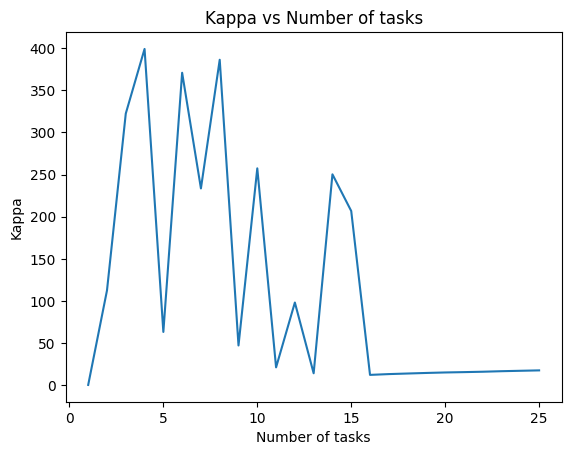

In [4]:
#plot
plt.figure()
plt.plot(np.arange(1,26),kappas)
plt.xlabel('Number of tasks')
plt.ylabel('Kappa')
plt.title('Kappa vs Number of tasks')
plt.show()


# CondHalf

In [5]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondHalf')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

kappas = []
for i in range(1,26):
    n_tasks = i+1
    unique_conditions = info_mdtb_1_All['cond_name'].unique()[:n_tasks]
    condition_indices = info_mdtb_1_All[info_mdtb_1_All['cond_name'].isin(unique_conditions)].index.tolist()
    data_t = data_mdtb_s1_All[:,condition_indices,:]
    cond_vec = np.tile(np.arange(1, n_tasks + 1), 2)
    part_vec = np.repeat(np.arange(1, 2 + 1), n_tasks)

    sym_type = 'sym'
    x_matrix = indicator(cond_vec)


    K = ar_model.K_full
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_vec,
                            subject_specific_kappa=False, parcel_specific_kappa=False, 
                            subjects_equal_weight=True)

    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_t])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                        fit_arrangement=False,
                                        fit_emission= True,
                                        first_evidence=False)
    
    kappas.append(M_1.emissions[0].kappa)

Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 22
Likelihood decreased - terminating on iteration 19
Likelihood decreased - terminating on iteration 20
Likelihood decreased - terminating on iteration 20
Likelihood decreased - terminating on iteration 17
Likelihood decreased - terminating on iterati

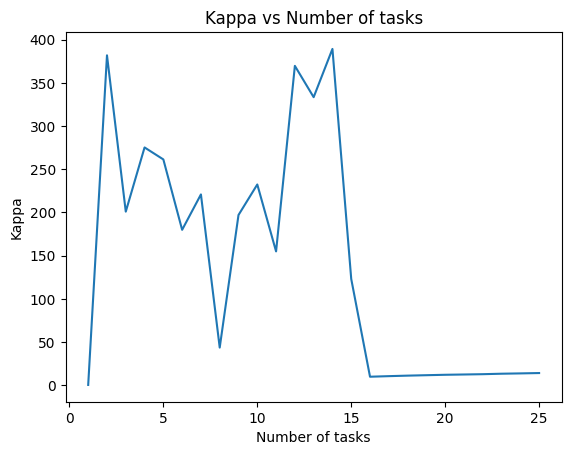

In [6]:
#plot
plt.figure()
plt.plot(np.arange(1,26),kappas)
plt.xlabel('Number of tasks')
plt.ylabel('Kappa')
plt.title('Kappa vs Number of tasks')
plt.show()


# CondRun

In [10]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0

kappas = []
for i in range(1,26):
    n_tasks = i+1
    unique_conditions = info_mdtb_1_All['cond_name'].unique()[:n_tasks]
    condition_indices = info_mdtb_1_All[info_mdtb_1_All['cond_name'].isin(unique_conditions)].index.tolist()
    data_t = data_mdtb_s1_All[:,condition_indices,:]
    cond_vec = np.tile(np.arange(1, n_tasks + 1), 16)
    part_vec = np.repeat(np.arange(1, 16 + 1), n_tasks)

    sym_type = 'sym'
    x_matrix = indicator(cond_vec)


    K = ar_model.K_full
    
    em_model = em.MixVMF(K=K, P=atlas.P, X=x_matrix, part_vec=part_vec,
                            subject_specific_kappa=False, parcel_specific_kappa=False, 
                            subjects_equal_weight=True)

    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([data_t])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                        fit_arrangement=False,
                                        fit_emission= True,
                                        first_evidence=False)
    
    kappas.append(M_1.emissions[0].kappa)

Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 1
Likelihood decreased - terminating on iteration 28
Likelihood decreased - terminating on iteration 28
Likelihood decreased - terminating on iteration 21
Likelihood decreased - terminating on iteration

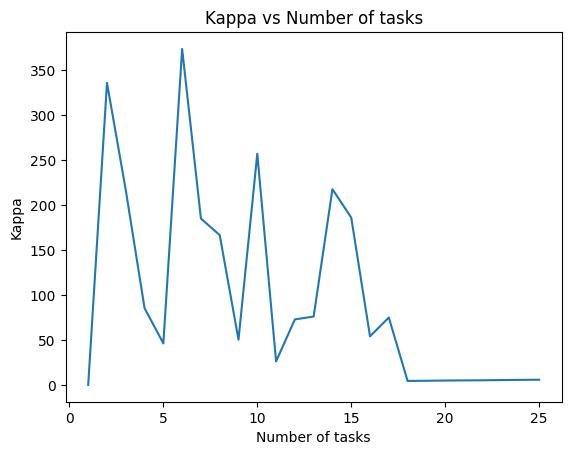

In [11]:
#plot
plt.figure()
plt.plot(np.arange(1,26),kappas)
plt.xlabel('Number of tasks')
plt.ylabel('Kappa')
plt.title('Kappa vs Number of tasks')
plt.show()

In [13]:
cond_vec

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
       26,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 26,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,
       15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
       23, 24, 25, 26,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
       14, 15, 16, 17, 18

# Play

In [31]:
atlas,_= am.get_atlas(atlas_str='MNISymC2')
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
data_mdtb_s1_All,info_mdtb_1_All  =MDTB_dataset.get_data(space='MNISymC2',ses_id='ses-s1',type='CondAll')
data_mdtb_s1_All[np.isnan(data_mdtb_s1_All)] = 0


In [53]:
n_tasks = 16
unique_conditions = info_mdtb_1_All['cond_name'].unique()[:n_tasks]
condition_indices = info_mdtb_1_All[info_mdtb_1_All['cond_name'].isin(unique_conditions)].index.tolist()
data_t = data_mdtb_s1_All[:,condition_indices,:]
cond_vec = np.tile(np.arange(1, n_tasks + 1), 1)
part_vec = np.repeat(np.arange(1, 1 + 1), n_tasks)

model = full_model 
sym_type = 'sym'
ar_model = model.arrange
ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())
x_matrix = indicator(cond_vec)


em_model = em.MixVMF(K=32, P=18290, X=x_matrix, part_vec=part_vec,
                        subject_specific_kappa=False, parcel_specific_kappa=False, 
                        subjects_equal_weight=True)

M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_1.initialize([data_t])

M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                    fit_arrangement=False,
                                    fit_emission= True,
                                    first_evidence=False)

emloglik = M_1.emissions[0].Estep()
U_individual = pt.softmax(emloglik, dim=1) # get data only parcellation

print(M_1.emissions[0].kappa)



/tmp/ipykernel_6866/2454104452.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ar_model.logpi = pt.tensor(ar_model.logpi, dtype=pt.get_default_dtype())


Likelihood decreased - terminating on iteration 1
tensor(315.2755)


In [54]:
# make list of strings numbers 1 to 24
subj_list = [str(i) for i in range(1,4)]

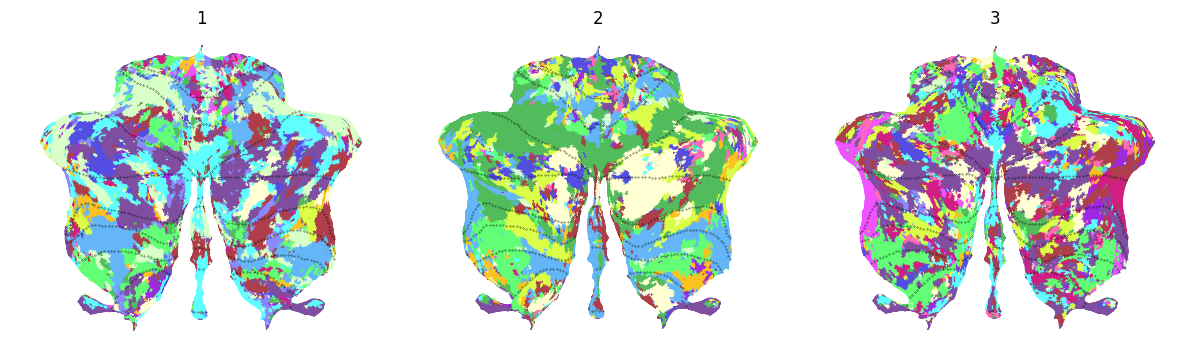

In [55]:
# Move to cpu, make npy, project into vols
U_individual_volumes = get_volumes(U_individual[:3].cpu().numpy())
plot_multi_flat(U_individual_volumes,
                         grid=(6,5),colorbar= False,
                        cmap= cmap,dtype='prob',
                        space = 'MNISymC',
                        render='matplotlib',
                        titles=subj_list,
                        bordersize = 0.5,
                        fig_size = (20,20))